In [113]:
import yaml
import torch
import numpy as np
from dotmap import DotMap
import matplotlib.pyplot as plt

# Use matplotlib's tex rendering
import matplotlib
matplotlib.rcParams['text.usetex'] = True

from pud.algos.ddpg import GoalConditionedCritic
from pud.visualizers.visualize import plot_agent_paths
from pud.utils import set_global_seed, set_env_seed
from pud.algos.lagrange.drl_ddpg_lag import DRLDDPGLag
from pud.collectors.constrained_collector import ConstrainedCollector
from pud.envs.safe_pointenv.pb_sampler import load_pb_set, sample_pbs_by_agent
from pud.algos.policies import SearchPolicy, ConstrainedSearchPolicy, MultiAgentSearchPolicy, ConstrainedMultiAgentSearchPolicy
from pud.envs.safe_pointenv.safe_wrappers import SafeGoalConditionedPointBlendWrapper, SafeGoalConditionedPointQueueWrapper, SafeGoalConditionedPointWrapper, safe_env_load_fn

#### Load the evaluation configuration

In [114]:
unconstrained_ckpt_file = "models/CenterDot/ckpt/ckpt_0300000"
config_file = "models/CenterDot/lag/2024-07-30-21-31-48/bk/bk_config.yaml"
constrained_ckpt_file = "models/CenterDot/lag/2024-07-30-21-31-48/ckpt/ckpt_0600000"
illustration_pb_file = "pud/envs/safe_pointenv/illustration_set/CenterDot_resize_3_linear_r3_4pts.txt"

with open(config_file, 'r') as f:
    config = yaml.safe_load(f)
config = DotMap(config)

# User defined parameters for evaluation
config.device = "cuda:0"
config.agent.cost_limit = 1.5
config.replay_buffer.max_size = 1000

set_global_seed(config.seed)

#### Load the evaluation environment

In [115]:
gym_env_wrappers = []
gym_env_wrapper_kwargs = []
for wrapper_name in config.wrappers:
    if wrapper_name == "SafeGoalConditionedPointWrapper":
        gym_env_wrappers.append(SafeGoalConditionedPointWrapper)
        gym_env_wrapper_kwargs.append(config.wrappers[wrapper_name].toDict())
    elif wrapper_name == "SafeGoalConditionedPointBlendWrapper":
        gym_env_wrappers.append(SafeGoalConditionedPointBlendWrapper)
        gym_env_wrapper_kwargs.append(config.wrappers[wrapper_name].toDict())
    elif wrapper_name == "SafeGoalConditionedPointQueueWrapper":
        gym_env_wrappers.append(SafeGoalConditionedPointQueueWrapper)
        gym_env_wrapper_kwargs.append(config.wrappers[wrapper_name].toDict())

eval_env = safe_env_load_fn(
    config.env.toDict(),
    config.cost_function.toDict(),
    max_episode_steps=config.time_limit.max_episode_steps,
    gym_env_wrappers=gym_env_wrappers,
    wrapper_kwargs=gym_env_wrapper_kwargs,
    terminate_on_timeout=True,
)

set_env_seed(eval_env, config.seed + 2)

[INFO] skipping the reset in PointEnv.__init__ because setup is not ready yet
[INFO] PointEnv setup: 0.0493316650390625 s
[INFO] SafePointEnv setup: 0.0032570362091064453 s


/scratch/miniconda3/envs/cc-sorb/lib/python3.9/site-packages/gym/spaces/box.py:128: UserWarning: WARN: Box bound precision lowered by casting to float32
  logger.warn(f"Box bound precision lowered by casting to {self.dtype}")
/scratch/miniconda3/envs/cc-sorb/lib/python3.9/site-packages/gym/core.py:317: DeprecationWarning: WARN: Initializing wrapper in old step API which returns one bool instead of two. It is recommended to set `new_step_api=True` to use new step API. This will be the default behaviour in future.
  deprecation(
/scratch/miniconda3/envs/cc-sorb/lib/python3.9/site-packages/gym/core.py:256: DeprecationWarning: WARN: Function `env.seed(seed)` is marked as deprecated and will be removed in the future. Please use `env.reset(seed=seed)` instead.
  deprecation(


#### Load the inference agent

In [116]:
obs_dim = eval_env.observation_space['observation'].shape[0]  # type: ignore
goal_dim = obs_dim
state_dim = obs_dim + goal_dim
action_dim = eval_env.action_space.shape[0]  # type: ignore
max_action = float(eval_env.action_space.high[0])  # type: ignore
print(f'Obs dim: {obs_dim},\n'
      f'Goal dim: {goal_dim},\n'
      f'State dim: {state_dim},\n'
      f'Action dim: {action_dim},\n'
      f'Max action: {max_action}')

agent = DRLDDPGLag(
        state_dim,  # Concatenating obs and goal
        action_dim,
        max_action,
        CriticCls=GoalConditionedCritic,
        device=torch.device(config.device),
        **config.agent,
    )

agent.load_state_dict(torch.load(constrained_ckpt_file))
agent.to(torch.device(config.device))
agent.eval()

Obs dim: 2,
Goal dim: 2,
State dim: 4,
Action dim: 2,
Max action: 1.0


/tmp/ipykernel_2374436/544677156.py:21: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  agent.load_state_dict(torch.load(constrained_ckpt_file))


DRLDDPGLag(
  (actor): GoalConditionedActor(
    (l1): Linear(in_features=4, out_features=256, bias=True)
    (l2): Linear(in_features=256, out_features=256, bias=True)
    (l3): Linear(in_features=256, out_features=2, bias=True)
  )
  (actor_target): GoalConditionedActor(
    (l1): Linear(in_features=4, out_features=256, bias=True)
    (l2): Linear(in_features=256, out_features=256, bias=True)
    (l3): Linear(in_features=256, out_features=2, bias=True)
  )
  (critic): EnsembledCritic(
    (critics): ModuleList(
      (0-2): 3 x GoalConditionedCritic(
        (l1): Linear(in_features=4, out_features=256, bias=True)
        (l2): Linear(in_features=258, out_features=256, bias=True)
        (l3): Linear(in_features=256, out_features=20, bias=True)
      )
    )
  )
  (critic_target): EnsembledCritic(
    (critics): ModuleList(
      (0-2): 3 x GoalConditionedCritic(
        (l1): Linear(in_features=4, out_features=256, bias=True)
        (l2): Linear(in_features=258, out_features=256, b

#### Sample a replay buffer to form our search graph

In [117]:
rb_vec = ConstrainedCollector.sample_initial_unconstrained_states(eval_env, config.replay_buffer.max_size)

agent.load_state_dict(torch.load(unconstrained_ckpt_file))
agent.to(torch.device(config.device))
agent.eval()
unconstrained_pdist = agent.get_pairwise_dist(rb_vec, aggregate=None)  # type: ignore
unconstrained_pcost = agent.get_pairwise_cost(rb_vec, aggregate=None)  # type: ignore

agent.load_state_dict(torch.load(constrained_ckpt_file))
constrained_pdist = agent.get_pairwise_dist(rb_vec, aggregate=None)  # type: ignore

if len(constrained_ckpt_file) > 0:
    agent.load_state_dict(torch.load(constrained_ckpt_file))
else:
    agent.load_state_dict(torch.load(unconstrained_ckpt_file))

/tmp/ipykernel_2374436/2538220623.py:3: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  agent.load_state_dict(torch.load(unconstrained_ckpt_file))
/tmp/ipykernel_2374436/25382

#### Sample (start, goal) problems for the agent

In [118]:
if len(illustration_pb_file) > 0:
    problems = load_pb_set(file_path=illustration_pb_file, env=eval_env, agent=agent)  # type: ignore
    problems = [problems[1]]
else:
    problems = sample_pbs_by_agent(
        K=10,
        min_dist=0,
        agent=agent,  # type: ignore
        env=eval_env,  # type: ignore
        target_val=10,
        num_states=100,
        ensemble_agg="mean",
        use_uncertainty=False,
        max_dist=eval_env.max_goal_dist,  # type: ignore
    )
    assert len(problems) > 0

eval_env.set_use_q(True)  # type: ignore
eval_env.set_prob_constraint(1.0)  # type: ignore
eval_env.set_pbs(pb_list=problems.copy())  # type: ignore

## Single-Agent Comparisons

### Unconstrained Low-Level Policy

In [119]:
agent.load_state_dict(torch.load(unconstrained_ckpt_file))
agent.to(torch.device(config.device))
agent.eval()

eval_env.duration = 300  # type: ignore
start, goal, unconstrained_observations, _, _, unconstrained_records = ConstrainedCollector.get_trajectories(
    agent,
    eval_env,
    1,
    habitat=False,
    wait=True,
    threshold=1e-3,
)

/tmp/ipykernel_2374436/3649534297.py:1: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  agent.load_state_dict(torch.load(unconstrained_ckpt_file))


### Unconstrained Low-Level Policy with Graph Search

In [120]:
eval_env.duration = 300  # type: ignore
eval_env.set_pbs(pb_list=problems.copy())  # type: ignore

cbs_config = {
    "seed": None,
    "use_experience": True,
    "use_cardinality": True,
    "collision_radius": 0.0,
    "risk_attribute": "cost",
    "edge_attributes": ["step"],
    "split_strategy": "disjoint",
    "max_distance": eval_env.max_goal_dist,
    "max_time": 60,
    "tree_save_frequency": 1,
    "logdir": "pud/mapf/unit_tests/logs/cbs",
}

search_policy = MultiAgentSearchPolicy(
    agent=agent,
    pdist=unconstrained_pdist,
    rb_vec=rb_vec,
    n_agents=1,
    open_loop=True,
    cbs_config=cbs_config,
    no_waypoint_hopping=True,
)

start, goal, unconstrained_search_observations, unconstrained_search_waypoints, _, unconstrained_search_records = ConstrainedCollector.get_trajectories(
    search_policy,
    eval_env,
    1,
    habitat=False,
    wait=True,
    threshold=1e-3,
)

Building graph
Time to find paths:  0.00782632827758789


### Constrained Low-Level Policy

In [121]:
agent.load_state_dict(torch.load(constrained_ckpt_file))
agent.to(torch.device(config.device))
agent.eval()

eval_env.duration = 300  # type: ignore
eval_env.set_pbs(pb_list=problems.copy())  # type: ignore

start,goal, constrained_observations, _, _, constrained_records = ConstrainedCollector.get_trajectories(
    agent,
    eval_env,
    1,
    habitat=False,
    wait=True,
    threshold=1e-3,
)

/tmp/ipykernel_2374436/2885998642.py:1: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  agent.load_state_dict(torch.load(constrained_ckpt_file))


### Constrained Low-Level Policy with Graph Search

In [122]:
eval_env.duration = 300  # type: ignore
eval_env.set_pbs(pb_list=problems.copy())  # type: ignore

cbs_config = {
    "seed": None,
    "use_experience": True,
    "use_cardinality": True,
    "collision_radius": 0.0,
    "risk_attribute": "cost",
    "split_strategy": "disjoint",
    "edge_attributes": ["step"],
    "max_distance": eval_env.max_goal_dist,
    "max_time": 60,
    "tree_save_frequency": 1,
    "logdir": "pud/mapf/unit_tests/logs/cbs",
}

search_policy = ConstrainedMultiAgentSearchPolicy(
    agent=agent,
    rb_vec=rb_vec,
    n_agents=1,
    pdist=constrained_pdist,
    pcost=unconstrained_pcost,
    open_loop=True,
    cbs_config=cbs_config,
    no_waypoint_hopping=True,
    max_cost_limit=0.75 * config.agent.cost_limit,
    ckpts={
        "unconstrained": unconstrained_ckpt_file,
        "constrained": constrained_ckpt_file,
    },
)

start, goal, constrained_search_observations, constrained_search_waypoints, _, constrained_search_records = ConstrainedCollector.get_trajectories(
    search_policy,
    eval_env,
    1,
    habitat=False,
    wait=True,
    threshold=1e-3,
)

Time to find paths:  0.10232114791870117


### Lagrangian Graph Search

In [123]:
eval_env.duration = 300  # type: ignore
eval_env.set_pbs(pb_list=problems.copy())  # type: ignore

cbs_config = {
    "seed": None,
    "use_experience": True,
    "use_cardinality": True,
    "collision_radius": 0.0,
    "risk_attribute": "cost",
    "split_strategy": "disjoint",
    "edge_attributes": ["step", "cost"],
    "max_distance": eval_env.max_goal_dist,
    "max_time": 60,
    "lagrangian": agent.lagrange.lagrangian_multiplier.data.numpy(),
    "tree_save_frequency": 1,
    "logdir": "pud/mapf/unit_tests/logs/cbs",
}

search_policy = ConstrainedMultiAgentSearchPolicy(
    agent=agent,
    rb_vec=rb_vec,
    n_agents=1,
    pdist=constrained_pdist,
    pcost=unconstrained_pcost,
    open_loop=True,
    cbs_config=cbs_config,
    no_waypoint_hopping=True,
    ckpts={
        "unconstrained": unconstrained_ckpt_file,
        "constrained": constrained_ckpt_file,
    },
)

start, goal, lagrangian_search_observations, lagrangian_search_waypoints, _, lagrangian_search_records = ConstrainedCollector.get_trajectories(
    search_policy,
    eval_env,
    1,
    habitat=False,
    wait=True,
    threshold=1e-3,
)

Time to find paths:  0.008289575576782227


### Biobjective Search

In [124]:
eval_env.duration = 300  # type: ignore
eval_env.set_pbs(pb_list=problems.copy())  # type: ignore

cbs_config = {
    "seed": None,
    "use_experience": False,
    "collision_radius": 0.0,
    "use_cardinality": False,
    "risk_attribute": "cost",
    "use_multi_objective": True,
    "split_strategy": "disjoint",
    "edge_attributes": ["step", "cost"],
    "max_distance": eval_env.max_goal_dist,
    "max_time": 60,
    "tree_save_frequency": 1,
    "logdir": "pud/mapf/unit_tests/logs/bocbs",
}

search_policy = ConstrainedMultiAgentSearchPolicy(
    agent=agent,
    rb_vec=rb_vec,
    n_agents=1,
    pdist=constrained_pdist,
    pcost=unconstrained_pcost,
    open_loop=True,
    cbs_config=cbs_config,
    no_waypoint_hopping=True,
    ckpts={
        "unconstrained": unconstrained_ckpt_file,
        "constrained": constrained_ckpt_file,
    },
)

start, goal, biobjective_search_observations, biobjective_search_waypoints, _, biobjective_search_records = ConstrainedCollector.get_trajectories(
    search_policy,
    eval_env,
    1,
    habitat=False,
    wait=True,
    threshold=1e-3,
)

First solution time (s):  17.244323015213013
Time to find paths:  17.245092630386353


### Collect Bounds 

In [125]:
eval_env.duration = 300  # type: ignore
eval_env.set_pbs(pb_list=problems.copy())  # type: ignore

cbs_config = {
    "seed": None,
    "use_experience": True,
    "use_cardinality": True,
    "collision_radius": 0.0,
    "risk_attribute": "cost",
    "split_strategy": "disjoint",
    "max_distance": eval_env.max_goal_dist,
    "lb_save_path": "pud/plots/exps/lb_centerdot.npy",
    "ub_save_path": "pud/plots/exps/ub_centerdot.npy",
    "max_time": 60,
    "tree_save_frequency": 1,
    "logdir": "pud/mapf/unit_tests/logs/cbs",
}

search_policy = ConstrainedMultiAgentSearchPolicy(
    agent=agent,
    rb_vec=rb_vec,
    n_agents=1,
    pdist=constrained_pdist,
    pcost=unconstrained_pcost,
    open_loop=True,
    cbs_config=cbs_config,
    max_cost_limit=np.inf,
    no_waypoint_hopping=True,
    ckpts={
        "unconstrained": unconstrained_ckpt_file,
        "constrained": constrained_ckpt_file,
    },
)

cbs_config["edge_attributes"] = ["cost"]
start, goal, _, _, _, _ = ConstrainedCollector.get_trajectories(
    search_policy,
    eval_env,
    1,
    habitat=False,
    wait=True,
    threshold=1e-3,
)

cbs_config["edge_attributes"] = ["step"]
eval_env.set_pbs(pb_list=problems.copy())  # type: ignore
start, goal, _, _, _, _ = ConstrainedCollector.get_trajectories(
    search_policy,
    eval_env,
    1,
    habitat=False,
    wait=True,
    threshold=1e-3,
)
bounds_data = {"cbs": {}, "lb": None, "ub": None}
cbs_lb = np.load(cbs_config["lb_save_path"])
cbs_ub = np.load(cbs_config["ub_save_path"])
bounds_data["cbs"]["lb"] = cbs_lb[-1]
bounds_data["cbs"]["ub"] = cbs_ub[-1]
    
cbs_config = {
    "seed": None,
    "use_experience": True,
    "use_cardinality": True,
    "collision_radius": 0.0,
    "risk_attribute": "cost",
    "split_strategy": "disjoint",
    "max_distance": eval_env.max_goal_dist,
    "max_time": 60,
    "tree_save_frequency": 1,
    "logdir": "pud/mapf/unit_tests/logs/cbs",
}
        
search_policy = ConstrainedMultiAgentSearchPolicy(
    agent=agent,
    rb_vec=rb_vec,
    n_agents=1,
    pdist=constrained_pdist,
    pcost=unconstrained_pcost,
    open_loop=True,
    cbs_config=cbs_config,
    no_waypoint_hopping=True,
    max_cost_limit=np.inf,
    ckpts={
        "unconstrained": unconstrained_ckpt_file,
        "constrained": constrained_ckpt_file,
    },
)

cbs_config["edge_attributes"] = ["cost"]
eval_env.set_pbs(pb_list=problems.copy())  # type: ignore
start, goal, _, _, _, records = ConstrainedCollector.get_trajectories(
    search_policy,
    eval_env,
    1,
    habitat=False,
    wait=True,
    threshold=1e-3,
)
all_success = True
bound_data = []
for agent_id in range(1):
    bound_data.append(records[agent_id]["cumulative_costs"])
    if not records[agent_id]["success"]:
        all_success = False
        break
if all_success:
    bounds_data["lb"] = np.sum(bound_data)
    
cbs_config["edge_attributes"] = ["step"]
eval_env.set_pbs(pb_list=problems.copy())  # type: ignore
start, goal, _, _, _, records = ConstrainedCollector.get_trajectories(
    search_policy,
    eval_env,
    1,
    habitat=False,
    wait=True,
    threshold=1e-3,
)

all_success = True
bound_data = []
for agent_id in range(1):
    bound_data.append(records[agent_id]["cumulative_costs"])
    if not records[agent_id]["success"]:
        all_success = False
        break
if all_success:
    bounds_data["ub"] = np.sum(bound_data)

Time to find paths:  0.07662725448608398
Time to find paths:  0.008560657501220703
Time to find paths:  0.07572102546691895
Time to find paths:  0.008681535720825195


### Risk Bounded Search with Uniform Allocater

In [151]:
eval_env.duration = 300  # type: ignore
eval_env.set_pbs(pb_list=problems.copy())  # type: ignore

cbs_config = {
    "seed": None,
    "use_experience": True,
    "use_cardinality": True,
    "collision_radius": 0.0,
    "risk_attribute": "cost",
    "split_strategy": "disjoint",
    "budget_allocater": "uniform",
    "edge_attributes": ["step", "cost"],
    "max_distance": eval_env.max_goal_dist,
    "max_time": 60,
    "tree_save_frequency": 1,
    "logdir": "pud/mapf/unit_tests/logs/rbcbs",
}

search_policy = ConstrainedMultiAgentSearchPolicy(
    agent=agent,
    rb_vec=rb_vec,
    n_agents=1,
    pdist=constrained_pdist,
    pcost=unconstrained_pcost,
    open_loop=True,
    cbs_config=cbs_config,
    max_cost_limit=np.inf,
    no_waypoint_hopping=True,
    ckpts={
        "unconstrained": unconstrained_ckpt_file,
        "constrained": constrained_ckpt_file,
    },
)

RISK_PERCENTAGE = 0.05
cbs_config["risk_bound"] = bounds_data["cbs"]["lb"] + RISK_PERCENTAGE * (bounds_data["cbs"]["ub"] - bounds_data["cbs"]["lb"])

start, goal, rb_search_observations, rb_search_waypoints, _, rb_search_records = ConstrainedCollector.get_trajectories(
    search_policy,
    eval_env,
    1,
    habitat=False,
    wait=True,
    threshold=1e-3,
)

Time to find paths:  0.3181772232055664


#### Plot the single-agent comparison

In [ ]:
unconstrained_observations = np.array(unconstrained_observations)
unconstrained_search_observations = np.array(unconstrained_search_observations)
constrained_observations = np.array(constrained_observations)
constrained_search_observations = np.array(constrained_search_observations)
lagrangian_search_observations = np.array(lagrangian_search_observations)
biobjective_search_observations = np.array(biobjective_search_observations)
rb_search_observations = np.array(rb_search_observations)


unconstrained_search_waypoints = np.array(unconstrained_search_waypoints)
constrained_search_waypoints = np.array(constrained_search_waypoints)
lagrangian_search_waypoints = np.array(lagrangian_search_waypoints)
biobjective_search_waypoints = np.array(biobjective_search_waypoints)


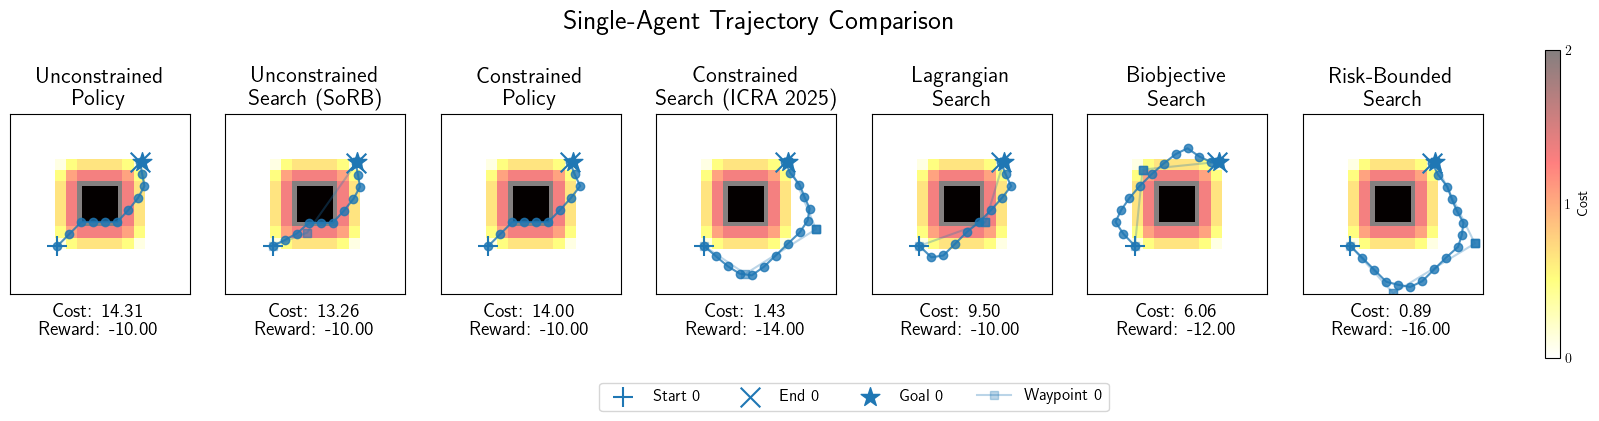

In [153]:
fig, axs = plt.subplots(1, 7, figsize=(20, 4))

for ax in axs:
    ax.imshow(eval_env.get_map(), cmap="binary", interpolation="nearest", alpha=1.0, extent=[0, 1, 0, 1])
    cmap = ax.imshow(eval_env.get_cost_map(), cmap="hot_r", interpolation="nearest", alpha=0.5, extent=[0, 1, 0, 1])
    ax.set_xticks([])
    ax.set_yticks([])

cbar = plt.colorbar(cmap, ax=axs, orientation="vertical", fraction=0.01, pad=0.04)
cbar.ax.tick_params(size=0)
cbar.set_ticks([0, 1, 2])

methods_records_map = {
    "Unconstrained\nPolicy": (unconstrained_records, unconstrained_observations),
    "Unconstrained\nSearch (SoRB)": (unconstrained_search_records, unconstrained_search_observations, unconstrained_search_waypoints),
    "Constrained\nPolicy": (constrained_records, constrained_observations),
    "Constrained\nSearch (ICRA 2025)": (constrained_search_records, constrained_search_observations, constrained_search_waypoints),
    "Lagrangian\nSearch": (lagrangian_search_records, lagrangian_search_observations, lagrangian_search_waypoints),
    "Biobjective\nSearch": (biobjective_search_records, biobjective_search_observations, biobjective_search_waypoints),
    "Risk-Bounded\nSearch": (rb_search_records, rb_search_observations, rb_search_waypoints),
}
titles = methods_records_map.keys()

def calculate_costs_and_rewards(records):
    cc = sum([record["cumulative_costs"] for record in records])
    reward = np.mean([record["rewards"] for record in records])
    return cc, reward

for agent_id in range(1):
    for ax, title in zip(axs, list(titles)):
        ax = plot_agent_paths(agent_id, start[agent_id], goal[agent_id], methods_records_map[title][1][agent_id], title, ax, wps=methods_records_map[title][2][agent_id] if "Search" in title else None)
        cc, reward = calculate_costs_and_rewards(methods_records_map[title][0])
        ax.text(0.5, -0.1, f"Cost: {cc:.2f}", horizontalalignment="center", verticalalignment="center", transform=ax.transAxes, weight='bold', fontsize=14)
        ax.text(0.5, -0.2, f"Reward: {reward:.2f}", horizontalalignment="center", verticalalignment="center", transform=ax.transAxes, weight='bold', fontsize=14)

cbar.set_label("Cost")
plt.legend(loc="lower center", bbox_to_anchor=(-2.5, -0.7), ncol=4, fontsize=12)
_ = plt.suptitle("Single-Agent Trajectory Comparison", fontsize=20)
# plt.savefig("pud/plots/figures/paper/single_agent_pointenv_comparison.svg", bbox_inches="tight")

In [154]:
bounds_data["lb"] + RISK_PERCENTAGE * (bounds_data["ub"] - bounds_data["lb"])

0.6041507737081435

In [155]:
bounds_data["cbs"]["lb"] + RISK_PERCENTAGE * (bounds_data["cbs"]["ub"] - bounds_data["cbs"]["lb"])

0.7192644365587342

In [156]:
lb = max(bounds_data["cbs"]["lb"], bounds_data["lb"])
ub = max(bounds_data["cbs"]["ub"], bounds_data["ub"])
print(f"Risk-bounded search: {lb + RISK_PERCENTAGE * (ub - lb):.2f}")

Risk-bounded search: 0.72


## Multi-Agent Comparisons

### Unconstrained Low-Level Policy

In [13]:
n_agents = 4
agent.load_state_dict(torch.load(unconstrained_ckpt_file))
agent.to(torch.device(config.device))
agent.eval()

eval_env.duration = 300  # type: ignore
eval_env.set_pbs(pb_list=problems.copy())  # type: ignore
start, goal, unconstrained_observations, _, _, unconstrained_records = ConstrainedCollector.get_trajectories(agent, eval_env, n_agents)

### Unconstrained Low-Level Policy with Graph Search

In [14]:
eval_env.duration = 300  # type: ignore
eval_env.set_pbs(pb_list=problems.copy())  # type: ignore

ma_search_policy = MultiAgentSearchPolicy(agent, rb_vec, n_agents, pdist=unconstrained_pdist, open_loop=True, no_waypoint_hopping=True)
start, goal, unconstrained_search_observations, unconstrained_search_waypoints, _, unconstrained_search_records = ConstrainedCollector.get_trajectories(ma_search_policy, eval_env, n_agents)

### Constrained Low-Level Policy

In [15]:
agent.load_state_dict(torch.load(constrained_ckpt_file))
agent.to(torch.device(config.device))
agent.eval()

eval_env.duration = 300  # type: ignore
eval_env.set_pbs(pb_list=problems.copy())  # type: ignore
start, goal, constrained_observations, _, _, constrained_records = ConstrainedCollector.get_trajectories(agent, eval_env, n_agents)

### Constrained Low-Level Policy with Graph Search

In [16]:
eval_env.duration = 300  # type: ignore
eval_env.set_pbs(pb_list=problems.copy())  # type: ignore

constrained_ma_search_policy = ConstrainedMultiAgentSearchPolicy(agent, rb_vec, n_agents, pdist=constrained_pdist, pcost=unconstrained_pcost, open_loop=True, no_waypoint_hopping=True, max_cost_limit=config.agent.cost_limit, ckpts={"unconstrained" : unconstrained_ckpt_file, "constrained" : constrained_ckpt_file})
start, goal, constrained_search_observations, constrained_search_waypoints, _, constrained_search_records = ConstrainedCollector.get_trajectories(constrained_ma_search_policy, eval_env, n_agents)

#### Plot the multi-agent comparison

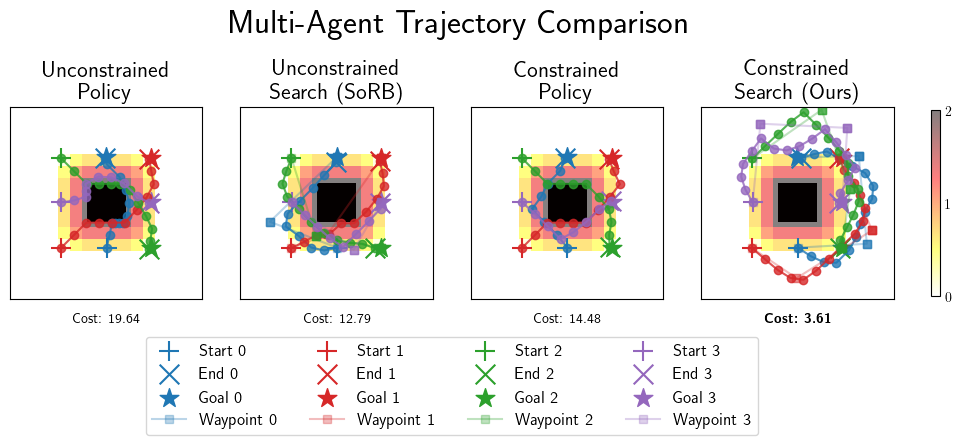

In [17]:
fig, axs = plt.subplots(1, 4, figsize=(12, 4))

for ax in axs:
    ax.imshow(eval_env.get_map(), cmap="binary", interpolation="nearest", alpha=1.0, extent=[0, 1, 0, 1])
    cmap = ax.imshow(eval_env.get_cost_map(), cmap="hot_r", interpolation="nearest", alpha=0.5, extent=[0, 1, 0, 1])
    ax.set_xticks([])
    ax.set_yticks([])

cbar = plt.colorbar(cmap, ax=axs, orientation="vertical", fraction=0.01, pad=0.04)
cbar.ax.tick_params(size=0)
cbar.set_ticks([0, 1, 2])

unconstrained_cc = max([record["cumulative_costs"] for record in unconstrained_records])
unconstrained_search_cc = max([record["cumulative_costs"] for record in unconstrained_search_records])
constrained_cc = max([record["cumulative_costs"] for record in constrained_records])
constrained_search_cc = max([record["cumulative_costs"] for record in constrained_search_records])
for agent_id in range(n_agents):
    agent_unconstrained_observations = np.array(unconstrained_observations[agent_id])
    agent_unconstrained_search_observations = np.array(unconstrained_search_observations[agent_id])
    agent_constrained_observations = np.array(constrained_observations[agent_id])
    agent_constrained_search_observations = np.array(constrained_search_observations[agent_id])
    
    agent_unconstrained_search_waypoints = np.array(unconstrained_search_waypoints[agent_id])
    agent_constrained_search_waypoints = np.array(constrained_search_waypoints[agent_id])

    axs[0] = plot_agent_paths(agent_id, start[agent_id], goal[agent_id], agent_unconstrained_observations, "Unconstrained\nPolicy", axs[0])
    axs[1] = plot_agent_paths(agent_id, start[agent_id], goal[agent_id], agent_unconstrained_search_observations, "Unconstrained\nSearch (SoRB)", axs[1], wps=agent_unconstrained_search_waypoints)
    axs[2] = plot_agent_paths(agent_id, start[agent_id], goal[agent_id], agent_constrained_observations, "Constrained\nPolicy", axs[2])
    axs[3] = plot_agent_paths(agent_id, start[agent_id], goal[agent_id], agent_constrained_search_observations, "Constrained\nSearch (Ours)", axs[3], wps=agent_constrained_search_waypoints)

axs[0].text(0.5, -0.1, f"Cost: {unconstrained_cc:.2f}", horizontalalignment="center", verticalalignment="center", transform=axs[0].transAxes, weight='bold')
axs[1].text(0.5, -0.1, f"Cost: {unconstrained_search_cc:.2f}", horizontalalignment="center", verticalalignment="center", transform=axs[1].transAxes, weight='bold')
axs[2].text(0.5, -0.1, f"Cost: {constrained_cc:.2f}", horizontalalignment="center", verticalalignment="center", transform=axs[2].transAxes, weight='bold')
axs[3].text(0.5, -0.1, rf"\textbf{{Cost: {constrained_search_cc:.2f}}}", horizontalalignment="center", verticalalignment="center", transform=axs[3].transAxes, weight='bold')

plt.legend(loc="lower center", bbox_to_anchor=(-1.3, -0.75), ncol=4, fontsize=12)
_ = plt.suptitle("Multi-Agent Trajectory Comparison", fontsize=24)
plt.savefig("pud/plots/figures/paper/multi_agent_pointenv_comparison.svg", bbox_inches="tight")

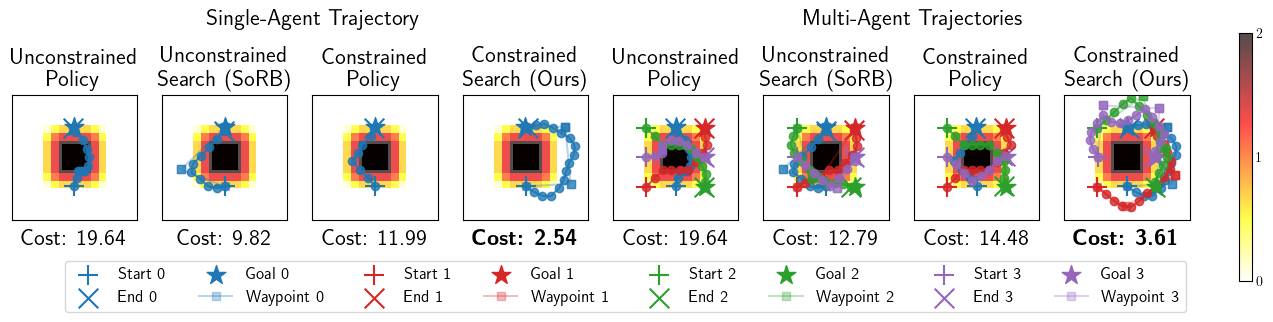

In [33]:
fig, axs = plt.subplots(1, 8, figsize=(16, 4))

for ax in axs:
    ax.imshow(eval_env.get_map(), cmap="binary", interpolation="nearest", alpha=1.0, extent=[0, 1, 0, 1])
    cmap = ax.imshow(eval_env.get_cost_map(), cmap="hot_r", interpolation="nearest", alpha=0.7, extent=[0, 1, 0, 1])
    ax.set_xticks([])
    ax.set_yticks([])

cbar = plt.colorbar(cmap, ax=axs, orientation="vertical", fraction=0.01, pad=0.04)
cbar.ax.tick_params(size=0)
cbar.set_ticks([0, 1, 2])

unconstrained_cc = max([record["cumulative_costs"] for record in unconstrained_records])
unconstrained_search_cc = max([record["cumulative_costs"] for record in unconstrained_search_records])
constrained_cc = max([record["cumulative_costs"] for record in constrained_records])
constrained_search_cc = max([record["cumulative_costs"] for record in constrained_search_records])

single_agent = 0
axs[0] = plot_agent_paths(single_agent, start[single_agent], goal[single_agent], np.array(unconstrained_observations[single_agent]), "Unconstrained\nPolicy", axs[0], use_agent_id=False)
axs[1] = plot_agent_paths(single_agent, start[single_agent], goal[single_agent], np.array(unconstrained_search_observations[single_agent]), "Unconstrained\nSearch (SoRB)", axs[1], wps=np.array(unconstrained_search_waypoints[single_agent]), use_agent_id=False)
axs[2] = plot_agent_paths(single_agent, start[single_agent], goal[single_agent], np.array(constrained_observations[single_agent]), "Constrained\nPolicy", axs[2], use_agent_id=False)
axs[3] = plot_agent_paths(single_agent, start[single_agent], goal[single_agent], np.array(constrained_search_observations[single_agent]), "Constrained\nSearch (Ours)", axs[3], wps=np.array(constrained_search_waypoints[single_agent]), use_agent_id=False)
axs[0].text(0.5, -0.15, f"Cost: {unconstrained_records[single_agent]['cumulative_costs']:.2f}", horizontalalignment="center", verticalalignment="center", transform=axs[0].transAxes, weight='bold', fontsize=16)
axs[1].text(0.5, -0.15, f"Cost: {unconstrained_search_records[single_agent]['cumulative_costs']:.2f}", horizontalalignment="center", verticalalignment="center", transform=axs[1].transAxes, weight='bold', fontsize=16)
axs[2].text(0.5, -0.15, f"Cost: {constrained_records[single_agent]['cumulative_costs']:.2f}", horizontalalignment="center", verticalalignment="center", transform=axs[2].transAxes, weight='bold', fontsize=16)
axs[3].text(0.5, -0.15, rf"\textbf{{Cost: {constrained_search_records[single_agent]['cumulative_costs']:.2f}}}", horizontalalignment="center", verticalalignment="center", transform=axs[3].transAxes, weight='bold', fontsize=16)

for agent_id in range(n_agents):
    agent_unconstrained_observations = np.array(unconstrained_observations[agent_id])
    agent_unconstrained_search_observations = np.array(unconstrained_search_observations[agent_id])
    agent_constrained_observations = np.array(constrained_observations[agent_id])
    agent_constrained_search_observations = np.array(constrained_search_observations[agent_id])
    
    agent_unconstrained_search_waypoints = np.array(unconstrained_search_waypoints[agent_id])
    agent_constrained_search_waypoints = np.array(constrained_search_waypoints[agent_id])

    axs[4] = plot_agent_paths(agent_id, start[agent_id], goal[agent_id], agent_unconstrained_observations, "Unconstrained\nPolicy", axs[4])
    axs[5] = plot_agent_paths(agent_id, start[agent_id], goal[agent_id], agent_unconstrained_search_observations, "Unconstrained\nSearch (SoRB)", axs[5], wps=agent_unconstrained_search_waypoints)
    axs[6] = plot_agent_paths(agent_id, start[agent_id], goal[agent_id], agent_constrained_observations, "Constrained\nPolicy", axs[6])
    axs[7] = plot_agent_paths(agent_id, start[agent_id], goal[agent_id], agent_constrained_search_observations, "Constrained\nSearch (Ours)", axs[7], wps=agent_constrained_search_waypoints)

axs[4].text(0.5, -0.15, f"Cost: {unconstrained_cc:.2f}", horizontalalignment="center", verticalalignment="center", transform=axs[4].transAxes, weight='bold', fontsize=16)
axs[5].text(0.5, -0.15, f"Cost: {unconstrained_search_cc:.2f}", horizontalalignment="center", verticalalignment="center", transform=axs[5].transAxes, weight='bold', fontsize=16)
axs[6].text(0.5, -0.15, f"Cost: {constrained_cc:.2f}", horizontalalignment="center", verticalalignment="center", transform=axs[6].transAxes, weight='bold', fontsize=16)
axs[7].text(0.5, -0.15, rf"\textbf{{Cost: {constrained_search_cc:.2f}}}", horizontalalignment="center", verticalalignment="center", transform=axs[7].transAxes, weight='bold', fontsize=16)

plt.legend(loc="lower center", bbox_to_anchor=(-3.5, -0.8), ncol=8, fontsize=12)
plt.text(2.4, 1.6, "Single-Agent Trajectory", horizontalalignment="center", verticalalignment="center", transform=axs[0].transAxes, fontsize=16)
plt.text(2.4, 1.6, "Multi-Agent Trajectories", horizontalalignment="center", verticalalignment="center", transform=axs[4].transAxes, fontsize=16)
# _ = plt.suptitle("Trajectory Comparisons", fontsize=24)
plt.savefig("pud/plots/figures/paper/pointenv_comparison_together.svg", bbox_inches="tight")